# Taller 03 v2: solver multiagente con GraphRAG y H200

Autor: Alejandro Chavez. Entrega preparada el 3 de octubre de 2026.

Este trabajo construye un sistema que recibe tareas en PDF, recupera restricciones y teoría, propone un plan, escribe Python, lo ejecuta aisladamente, critica y produce el entregable. Se implementan ocho responsabilidades con un bucle propio y se evalúa frente a una ablación y a una memoria de scripts aprobados.

**Procedencia del material.** Por petición del usuario se reconstruyó el kit `solver-v2` a partir del PDF vigente y los archivos disponibles. Contiene tres enunciados de práctica propios, dos controles reales aportados y notas teóricas del curso. No se presenta como una copia del paquete institucional. Los identificadores `demo-A/B/C` nombran las tres prácticas propias del kit. Se incluyen 25 checks centrales de práctica, 9 diagnósticos adicionales y 21 checks de los controles. Las respuestas esperadas se calculan con código independiente.

La inferencia y los embeddings de las corridas finales se hicieron en la H200 de la universidad. Codex editó y verificó los archivos como orquestador; no se generaron subagentes Codex para estas corridas. El código científico se ejecutó localmente en macOS. Se generaron exactamente dos ilustraciones mediante Codex, con sus prompts; las gráficas y diagramas se construyeron mediante código. Se conservan los fallos medidos: completar la entrega del taller no significa que un solver haya aprobado todos los checks.

In [1]:
from pathlib import Path
import json, sys, hashlib
import pandas as pd
from IPython.display import display, Markdown, Image
BASE = Path.cwd()
assert (BASE/'solver_pdf.py').exists(), 'Abre el notebook desde la carpeta de la entrega'
sys.path.insert(0,str(BASE))
def load(relative): return json.loads((BASE/relative).read_text())
def artifact(raw):
    p=Path(raw)
    local=BASE/str(p).split('taller 3/',1)[-1]
    if local.exists(): return local
    return p
r = pd.read_csv(BASE/'resultados_solver.csv')
s = pd.read_csv(BASE/'resumen_solver.csv')
checks = pd.read_csv(BASE/'checks_solver.csv')
roles = pd.read_csv(BASE/'consumo_por_agente.csv')
assert len(r)==15 and len(r.modelo.unique())==1
print('Corridas:',len(r),'modelo:',r.modelo.unique()[0])
print('Estas celdas analizan evidencia. RUN_LIVE=False evita nuevas peticiones H200.')

Corridas: 15 modelo: zai-org/GLM-5.3-Flash
Estas celdas analizan evidencia. RUN_LIVE=False evita nuevas peticiones H200.


## Parte 0. Tres fallas que pueden pasar inadvertidas

### 0.a. Un reporte sin ejecución

Se hizo una única llamada H200 con el enunciado reconstruido A y sin herramientas. El modelo reconoció que no podía medir las exactitudes y dejó vacía la lista de estimaciones. Por ello **no se reprodujo la invención de exactitudes** observada por el profesor: cambiaron el enunciado, el modelo servido y el prompt. La salida completa está en `solver-v2/parte0/a_sin_ejecutar.json`, junto con ruta, fecha, consumo y el contraste calculado posteriormente.

Que una cifra esté cerca de la real no la hace aceptable: falta la ejecución que vincula datos, partición, script y resultado. Aquí no hubo una cifra inventada de exactitud que cambiara la conclusión; asignar a esta corrida el cruce de curvas del ejemplo del PDF sería falsear la observación. Para detectar el problema sin conocer la respuesta, el verificador debe exigir un artefacto ejecutado y comprobar que cada cifra del reporte procede de él o del enunciado.

La respuesta sin herramientas sí muestra un límite: anuncia `curva.png` aunque el modelo no creó el archivo. También calcula el tamaño de prueba usando `round`; el protocolo general de scikit-learn usa el redondeo requerido por su API y no debe deducirse de ese ejemplo. Su tabla deja las exactitudes por medir. Una explicación plausible con código propuesto sigue sin ser un experimento.

Salida observada: «**Nota de transparencia:** no tengo herramientas de ejecución, por lo que **no puedo medir** `accuracy_nb`, `accuracy_lr` ni los valores de la curva de aprendizaje. Este reporte entrega el protocolo completo, el código reproducible y la discusión; los valores medidos deben completarse ejecutando el código. No invento cifras ni citas.»

| Métrica          | LLM sin herramientas   |   Referencia ejecutada |
|:-----------------|:-----------------------|-----------------------:|
| accuracy_nb      | por medir              |                 0.9386 |
| accuracy_lr      | por medir              |                 0.9825 |
| accuracy_lr_f005 | por medir              |                 0.9386 |
| accuracy_lr_f020 | por medir              |                 0.9737 |
| accuracy_lr_f100 | por medir              |                 0.9825 |

In [2]:
a=load('solver-v2/parte0/a_sin_ejecutar.json')
display(pd.DataFrame(a['routes']));display(a['usage'])
display(pd.DataFrame([{'métrica':k,'referencia ejecutada':v} for k,v in a['executed_reference'].items()]))
print('Exactitudes estimadas por el LLM:', a['report']['cifras_estimadas'])
print('Reporte íntegro disponible en solver-v2/parte0/a_sin_ejecutar.json')
assert a['report']['cifras_estimadas']==[]

,url,id,verified_at
0,http://172.28.230.10:12555/v1,zai-org/GLM-5.3-Flash,2026-10-03T21:01:40.224724+00:00
1,http://172.28.230.10:12559/v1,zai-org/GLM-5.3-Flash,2026-10-03T21:01:40.257465+00:00


{'tokens_entrada': 602, 'tokens_salida': 2214}

,métrica,referencia ejecutada
0,n_samples,569.000000
1,n_train,455.000000
2,n_test,114.000000
3,accuracy_nb,0.938596
4,accuracy_lr,0.982456
5,accuracy_lr_f005,0.938596
6,accuracy_lr_f020,0.973684
7,accuracy_lr_f100,0.982456


Exactitudes estimadas por el LLM: []
Reporte íntegro disponible en solver-v2/parte0/a_sin_ejecutar.json


### 0.b. Recuperación plana frente a dependencias

El script TF-IDF top-2 recuperó las Partes 4 y 3 del nuevo enunciado A. Ninguna contenía los tres hechos del protocolo: dataset, tamaño de prueba y estratificación. La regla de referencias siguió «Parte 1» y el contexto pasó de **0 a 3 hechos**. El proceso es local y no llama a ningún modelo.

La falla nace en la recuperación: antes de generar, el contexto ya perdió una restricción necesaria. Un LLM podría completar el vacío con una división habitual o con otro dataset y producir código válido para una tarea distinta. La arista se extrae con una regla porque la referencia es una obligación literal, reproducible y auditable; las relaciones semánticas del LLM se añaden encima de ese esqueleto.

In [3]:
b=load('solver-v2/parte0/b_rag.json');display(b)
assert len(b['facts_before'])==0 and len(b['facts_after'])==3

{'query': 'con qué datos y con qué partición se calcula la curva de aprendizaje',
 'flat_sections': ['seccion_4', 'seccion_3'],
 'graph_sections': ['seccion_1', 'seccion_3', 'seccion_4'],
 'facts_before': [],
 'facts_after': ['load_breast_cancer', 'test_size=0.2', 'stratify=y'],
 'scope': 'kit reconstruido; salida calculada sin LLM'}

### 0.c. Código de salida cero con fuga

Un árbol de decisión entrenado y evaluado con el mismo `X` produjo `accuracy=1.0`, escribió JSON y terminó con código cero. Un evaluador ingenuo lo aceptó. La guarda AST detectó la misma expresión en ajuste y evaluación; la plausibilidad numérica añadió una alerta. Para ejecutar este ejemplo deliberadamente incorrecto se omitió únicamente esa guarda sobre un script fijo confiable; se conservó el aislamiento del sistema operativo.

La heurística no detecta todas las fugas: ajustar un escalador con todo el dataset antes de dividir puede pasar inadvertido. Las comprobaciones por código deben ir antes del crítico; el LLM revisa después el sentido del protocolo y sus condiciones. Una exactitud perfecta es una alerta, no una prueba automática de fuga.

In [4]:
c=load('solver-v2/parte0/c_fuga.json');display(c)
assert c['naive_approved'] and c['static_rejection'] and c['plausibility_alert']

{'naive_approved': True,
 'results': {'metrics': {'accuracy': 1.0}, 'figures': []},
 'static_rejection': 'posible fuga: entrenar y evaluar con la misma expresión',
 'plausibility_alert': True,
 'scope': 'cifra alta es alerta; fuga confirmada por entrenar y evaluar sobre X'}

## Parte 1. Arquitectura, grafo y controles

### Ocho responsabilidades y aristas condicionales

El lector extrae páginas, tablas y ligaduras y detecta páginas que requieren OCR. El indexador crea secciones, dependencias, entidades normalizadas y comunidades. El planificador propone subtareas, criterios y dependencias. El investigador recupera contexto citado. El programador propone un script. El ejecutor es Python, sin LLM. El crítico revisa después de las comprobaciones genéricas. El redactor responde las preguntas y produce el formato solicitado.

El bucle permite replanificar si el DAG es inválido; devolver una corrección al programador si ejecución o crítica rechazan; avanzar por aprobación; registrar fallo al alcanzar el tope y continuar tareas independientes; bloquear red hasta decisión humana; y redactar al terminar la cola o al agotarse el presupuesto. Este bucle propio es una alternativa permitida a LangGraph.

![Orquestador: roles, correcciones y condiciones de salida.](imagenes/solver_orquestador.png)

### Las seis correcciones

| Corrección obligatoria | Código responsable | Qué verifica |
|---|---|---|
| Plan como DAG | `validate_plan` | IDs, referencias existentes, ausencia de ciclos y cobertura formal de secciones. |
| Esqueleto GraphRAG | `build_sections`, `dependency_closure`, `KnowledgeGraph` | Referencias por reglas, cierre literal, embeddings BGE-M3, entidades y relaciones H200 normalizadas, comunidades Louvain resumidas. |
| Sandbox | `guard_script`, `execute_script` | AST antes del proceso, cwd propio, entorno vacío, Seatbelt, timeout y killpg, red bloqueada. |
| Resultados antes del crítico | `validate_results` | JSON, cifras finitas, salida del proceso, artefactos y señales heurísticas de fuga. |
| Procedencia antes de publicar | `render_provenance` | Sustituye placeholders y rechaza cifras ajenas a ejecución o enunciado; conserva ledger. |
| Trazas en todos los caminos | `Trace`, `LocalTrace`, bloque `finally` | Peticiones, respuestas, modelo, uso, latencia, errores, decisiones y resultados de procesos. |

Estas capas tienen límites concretos: cobertura formal no equivale a interpretar bien una sección, AST no prueba seguridad general y una cifra con procedencia puede estar descrita incorrectamente. Los estados del solver y el golden se reportan por separado.

,id,tipo,sections,depends_on,description,criteria
0,t1,conceptual,[introduccion],[],Redactar la Introducción del reporte: objetivo...,[Explica el objetivo generativo vs discriminat...
1,t2,calculo,[seccion_1],[],"Cargar load_breast_cancer de sklearn, hacer tr...",[Usa load_breast_cancer sin descargas externas...
2,t3,calculo,[seccion_2],[t2],Entrenar GaussianNB y Pipeline(StandardScaler(...,"[Escalador ajustado solo con train, Reporta ac..."
3,t4,calculo,[seccion_3],[t2],Calcular la curva de aprendizaje con la misma ...,"[Mismas particiones y semilla, Tres fracciones..."
4,t5,conceptual,[seccion_4],"[t3, t4]",Redactar Discusión y entrega: explicar con qué...,"[Explica datos y partición de la curva, Distin..."


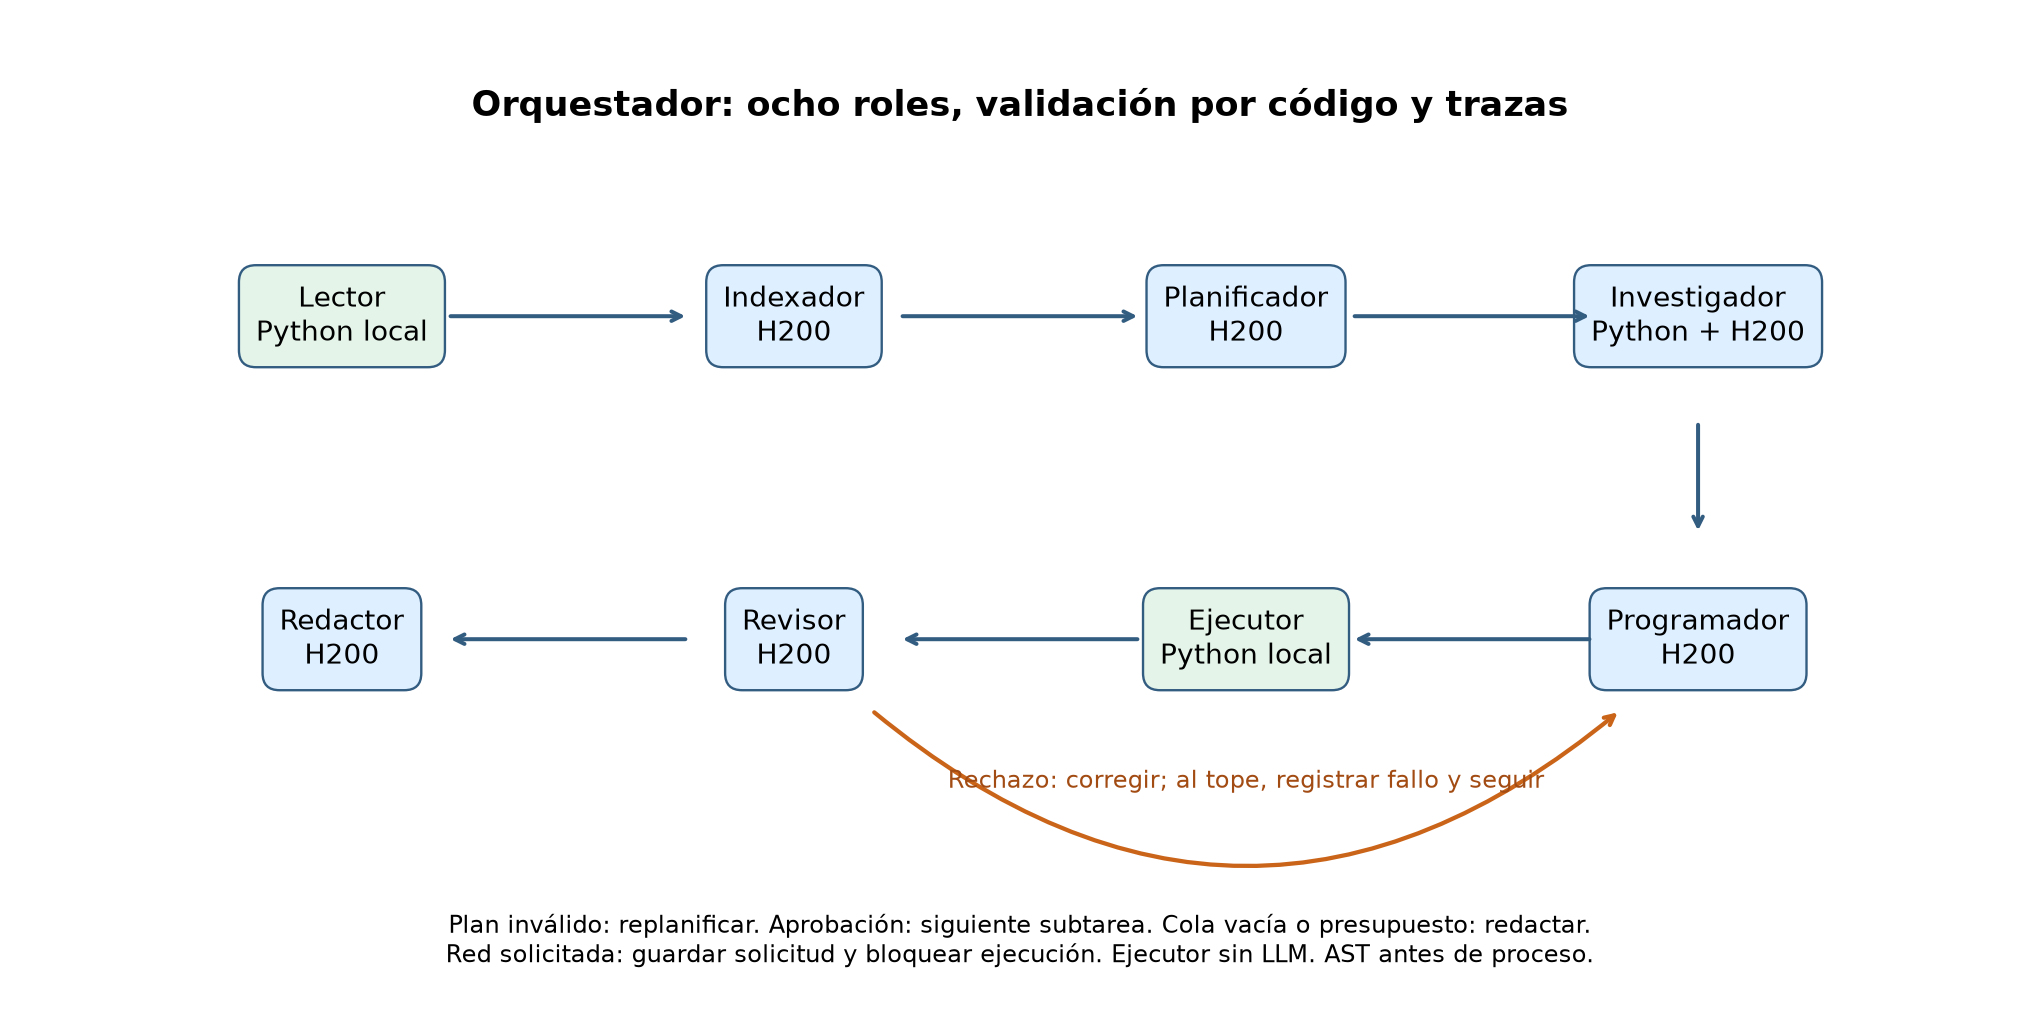

[{'timestamp': '2026-10-03T21:05:02.969669+00:00',
  'event': 'models_verified',
  'models': [{'url': 'http://172.28.230.10:12555/v1',
    'id': 'zai-org/GLM-5.3-Flash',
    'verified_at': '2026-10-03T21:05:02.935564+00:00'},
   {'url': 'http://172.28.230.10:12559/v1',
    'id': 'zai-org/GLM-5.3-Flash',
    'verified_at': '2026-10-03T21:05:02.969063+00:00'}]}]

In [5]:
from solver_pdf import Solver, validate_plan, dependency_closure, render_provenance
case = BASE/'corridas/tarea-demo-A-completo-kit'
plan=load('corridas/tarea-demo-A-completo-kit/plan.json')
sections=load('corridas/tarea-demo-A-completo-kit/grafo.json')
assert validate_plan(plan,sections)==[]
display(pd.DataFrame(plan['subtareas']))
display(Image(filename=str(BASE/'imagenes/solver_orquestador.png')))
events=[json.loads(line) for line in (case/'traza.jsonl').read_text().splitlines()]
display([e for e in events if e['event']=='models_verified'])

### Grafo del enunciado y teoría completa disponible

El enunciado A tiene cuatro partes. La curva remite al protocolo de la Parte 1; la discusión remite a la curva. Seguir estas aristas recupera condiciones que la similitud puede perder. El diagrama siguiente sale de `grafo.json`, no de relaciones inventadas para ilustrar el sistema.

![Dependencias determinísticas del enunciado A reconstruido.](imagenes/solver_grafo_demo_A.png)

El kit conserva el texto completo de las notas teóricas disponibles en capítulos numerados del curso, excluyendo índices, prácticas, talleres y recursos visuales. El inventario guarda sus hashes. Los fragmentos se vectorizan completos; la extracción de entidades H200 se hizo sobre cada documento completo. La preparación común queda en `solver-v2/indice_curso/` y se reutiliza por hash en todas las variantes. Los resúmenes de comunidades usan extractos limitados de cada documento; orientan la búsqueda global y no reemplazan las fuentes literales. Las imágenes incrustadas en notas no se interpretaron mediante OCR.

La recuperación completa entrega siempre la sección y su cierre de dependencias, añade semillas por embeddings y resúmenes de comunidades pertinentes. La ablación entrega solamente los cuatro fragmentos más similares por embeddings: conserva la preparación para comparar recuperación con la misma base y el mismo modelo, pero elimina cierre, vecindad y búsqueda global. Los costes comunes de preparar la base se presentan aparte.

|   Documentos teóricos |   Fragmentos |   Comunidades |   Tokens entrada comunes |   Tokens salida comunes |
|----------------------:|-------------:|--------------:|-------------------------:|------------------------:|
|                   103 |         1056 |            26 |                   280902 |                   82177 |

Modelo medido: `zai-org/GLM-5.3-Flash`. Endpoints: `http://172.28.230.10:12555/v1` y `http://172.28.230.10:12559/v1`. Verificación UTC: 2026-10-03T20:59:16.412857+00:00. Embeddings: `bge-m3:latest`, `http://172.28.230.10:11434/api/embed`.

{'documents': 103,
 'sections': 1056,
 'communities': 26,
 'model': 'zai-org/GLM-5.3-Flash',
 'tokens_entrada': 280902,
 'tokens_salida': 82177}

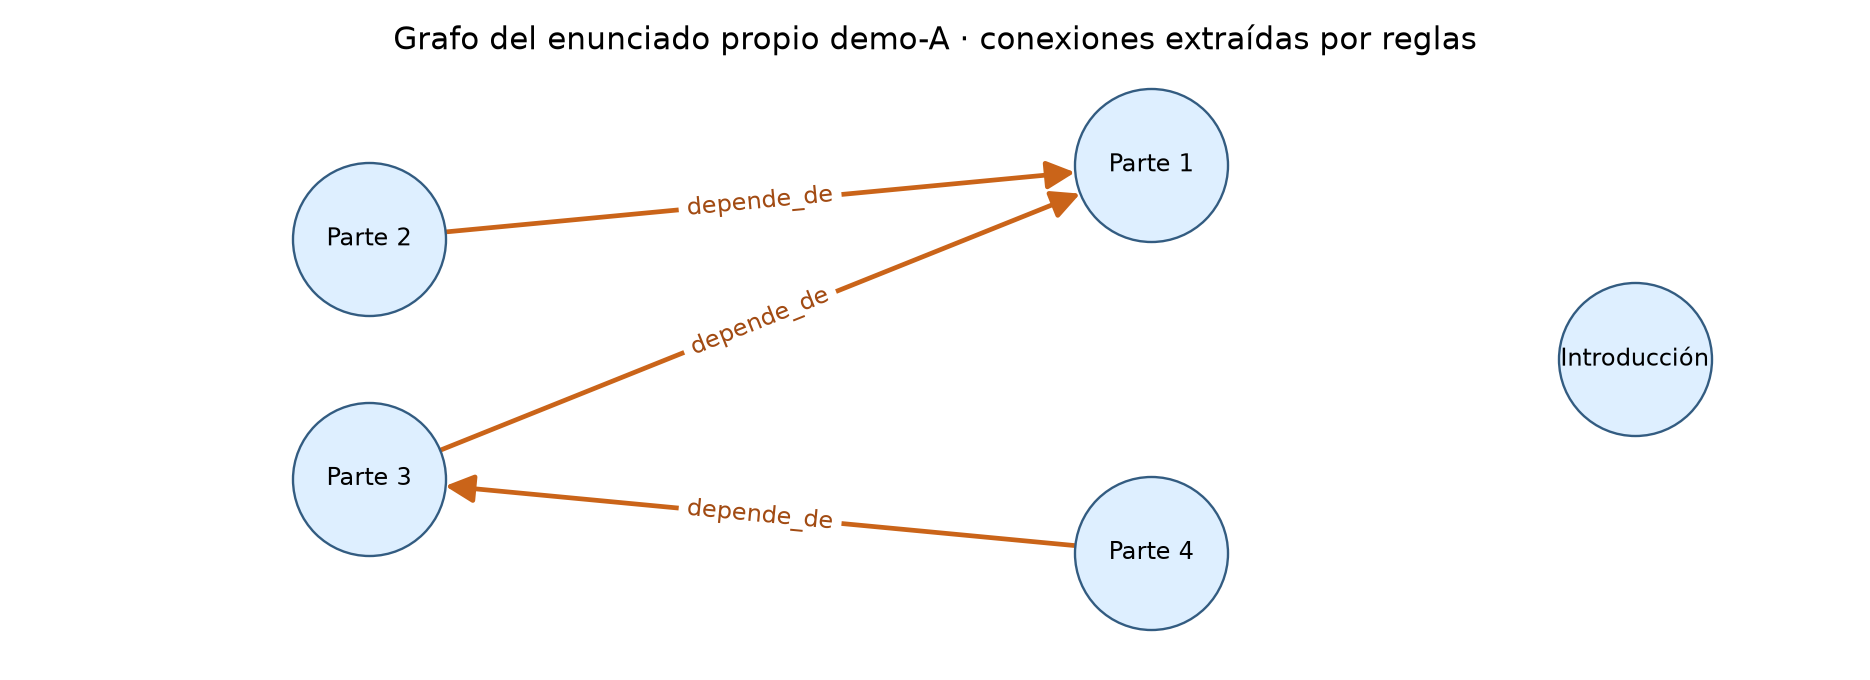

,sección,título,depende de
0,introduccion,Introducción,[]
1,seccion_1,Parte 1: protocolo fijo,[]
2,seccion_2,Parte 2: modelos,[seccion_1]
3,seccion_3,Parte 3: curva de aprendizaje,[seccion_1]
4,seccion_4,Parte 4: discusión y entrega,[seccion_3]


Todos los hashes del corpus coinciden.


In [6]:
index=load('solver-v2/indice_curso/resumen.json')
display({k:index[k] for k in ['documents','sections','communities','model','tokens_entrada','tokens_salida']})
manifest=load('solver-v2/manifest.json')
assert index['documents']==manifest['theory_documents']
for doc in load('solver-v2/material_curso.json'):
    local=BASE/'solver-v2/notas-teoricas'/doc['id']
    assert hashlib.sha256(local.read_bytes()).hexdigest()==doc['sha256']
display(Image(filename=str(BASE/'imagenes/solver_grafo_demo_A.png')))
display(pd.DataFrame([{'sección':k,'título':v['title'],'depende de':v['depends_on']} for k,v in sections.items()]))
print('Todos los hashes del corpus coinciden.')

### Evidencia de rechazo H200

Una prueba adicional sembró el error `softmax(logits * T)`. Pasó los checks genéricos de ejecución, pero el crítico H200 lo rechazó porque debe dividirse por temperatura. El programador H200 reparó el script, se ejecutó nuevamente y el crítico lo aprobó. Se conservan ambos scripts y las decisiones completas en `solver-v2/critico_forzado/`. Es un fallo forzado explícito, separado de las corridas del golden.

In [7]:
critical=load('solver-v2/critico_forzado/resumen.json')
display({k:critical[k] for k in ['first_rejected','final_approved','attempts','decisions','model','usage']})
assert critical['first_rejected'] and critical['final_approved']

{'first_rejected': True,
 'final_approved': True,
 'attempts': 2,
 'decisions': [{'approved': False,
   'correction': "El código multiplica los logits por T (`scaled=[x*T for x in logits]`) en lugar de dividirlos, violando el criterio 'la temperatura divide los logits'. Con la corrección `scaled=[x/T for x in logits]`, los valores correctos son: prob0_T05 = e^4/(e^4+e^2+1) ≈ 0.8668, prob0_T1 ≈ 0.6652 (correcto, pues x*1 = x/1), prob0_T2 = e^1/(e^1+e^0.5+1) ≈ 0.5065. Los resultados reportados para T=0.5 y T=2 están intercambiados respecto a los valores correctos (multiplicar por 0.5 equivale a dividir por 2). La estabilidad numérica (resta del máximo) sí está bien implementada."},
  {'approved': True,
   'correction': 'Verificado: el código divide los logits por T (no multiplica), usa softmax estable restando el máximo, y los valores reportados coinciden con el cálculo manual: T=0.5 → $e^4/(e^4+e^2+1)\\approx 0.8668$; T=1 → $e^2/(e^2+e+1)\\approx 0.6652$; T=2 → $e^1/(e^1+e^{0.5}+1)\\app

## Parte 2. Golden independiente, ablación y fallos

### Diseño del verificador reconstruido

Los tres ejercicios de práctica cubren NB frente a regresión logística y una curva de aprendizaje; temperatura, top-p, entropía y muestreo; y TF-IDF frente a LSA con datos en una tabla PDF. Los controles reales añaden un benchmark lista/diccionario y diferencias centrales con predicción previa. Hay entregables Markdown, notebook ejecutado y PDF de hasta dos páginas.

El golden tiene 25 checks centrales de práctica y 9 diagnósticos adicionales, más los 21 de controles reales. Cada control contiene al menos dos `cifra` con `verdad_py`, checks de formato y procedencia. Dos de los checks reales son diagnósticos semánticos añadidos después de revisar salidas narrativas: detectan que los candidatos no coinciden en el punto indicado. Su carácter post hoc está marcado en el JSON; no son una comparación preregistrada. Se mantienen todos los checks en la tabla detallada; no se eliminan los que fallan. El evaluador recalcula las referencias desde funciones conocidas, sin ejecutar código del LLM ni instrucciones arbitrarias del JSON.

La trampa de A exige usar únicamente train al ajustar el escalador y mantener el test para todos los tamaños. La de B exige incluir el token que cruza el umbral del núcleo. Control 3 requiere predicción antes del primer proceso y conservar en CSV los ceros numéricos. Control 1 tiene un oracle de cantidades y protocolo; sus tiempos no tienen una respuesta fija, porque dependen del estado del equipo. Las restricciones estáticas se declaran heurísticas y no constituyen un analizador universal.

In [8]:
from referencias_practica import truths as practice_truths
from referencias_controles import truths as real_truths
golden=load('solver-v2/golden_tareas.json')
display(pd.DataFrame([{'tarea':t['id'],'checks':len(t['checks']),'verdad_py':sum('verdad_py' in c for c in t['checks'])} for t in golden['tareas']]))
assert sum(c['grupo']=='central' for t in golden['tareas'] for c in t['checks'])==25
display(practice_truths());display(real_truths())

,tarea,checks,verdad_py
0,demo-A,13,8
1,demo-B,12,7
2,demo-C,9,4
3,control-1,8,3
4,control-3,13,6


{'demo-A': {'n_samples': 569,
  'n_train': 455,
  'n_test': 114,
  'accuracy_nb': 0.9385964912280702,
  'accuracy_lr': 0.9824561403508771,
  'accuracy_lr_f005': 0.9385964912280702,
  'accuracy_lr_f020': 0.9736842105263158,
  'accuracy_lr_f100': 0.9824561403508771},
 'demo-B': {'prob0_T05': np.float64(0.8668133321973347),
  'prob0_T1': np.float64(0.6652409557748218),
  'prob0_T2': np.float64(0.506480391055654),
  'entropy_T1': np.float64(0.8323955818399389),
  'nucleus_size': 2,
  'nucleus_mass': 0.9099694268296195,
  'sample_freq0': 0.6719},
 'demo-C': {'n_documents': 6,
  'n_queries': 3,
  'tfidf_p2_mean': 1.0,
  'lsa_p2_mean': 0.6666666666666666}}

{'control-1': {'n_menor': 10000, 'n_mayor': 100000, 'consultas_ausentes': 200},
 'control-3': {'g_num_h_1e-5': 10.000000000198739,
  'g_num_h_1e-16': 0.0,
  'gA_en_w': 10.0,
  'gB_en_w': 4.0}}

### Comparación por tarea

Se hicieron nuevas corridas con el kit reconstruido y el corpus completo disponible. Cada pareja usa el mismo PDF, modelo, golden y base. El presupuesto, timeout y top-k permanecen constantes. Los planes y reintentos pueden variar: una sola corrida por tarea y variante no demuestra causalidad.

La recuperación de tablas se corrigió antes de fijar el conjunto final; se declara esta intervención en la implementación. Las tablas y el análisis utilizan exclusivamente las 15 corridas finales identificadas por tarea y variante. Los tokens se suman desde todas las llamadas LLM de la traza seleccionada, incluidos errores y reintentos. La preparación común de teoría se cuenta una sola vez y no se atribuye ficticiamente a cada tarea. Los embeddings se registran por separado. `duracion_s` suma latencias de llamadas y procesos; `pared_s` es la duración real registrada por tarea. El runner ejecuta dos tareas completas a la vez, mientras las subtareas de cada una siguen siendo secuenciales; no se eligió la extensión de paralelismo de subtareas.

| Variante   | Tarea     | Estado     |   Intentos |   Entrada |   Salida |   Pared (s) |
|:-----------|:----------|:-----------|-----------:|----------:|---------:|------------:|
| completo   | demo-A    | completado |          3 |     53585 |    13558 |    144.8400 |
| completo   | demo-B    | completado |          2 |     46933 |    13840 |    134.2975 |
| completo   | demo-C    | completado |          2 |     47576 |    11271 |    117.8554 |
| completo   | control-1 | parcial    |          2 |     42527 |     8611 |     87.0468 |
| completo   | control-3 | completado |          4 |     68445 |    16493 |    128.6901 |
| sin_grafo  | demo-A    | completado |          3 |     53070 |    15383 |    128.4038 |
| sin_grafo  | demo-B    | completado |          2 |     38332 |    12839 |     98.6886 |
| sin_grafo  | demo-C    | parcial    |          3 |     44912 |    17563 |    129.2439 |
| sin_grafo  | control-1 | completado |          1 |     29119 |     8288 |     72.0241 |
| sin_grafo  | control-3 | completado |          5 |     41310 |    13148 |     78.0581 |
| memoria    | demo-A    | parcial    |          3 |     51259 |    11433 |    136.8706 |
| memoria    | demo-B    | completado |          2 |     39199 |     8444 |     90.9341 |
| memoria    | demo-C    | completado |          2 |     47629 |    14639 |    161.1928 |
| memoria    | control-1 | completado |          1 |     38962 |     7286 |     70.8071 |
| memoria    | control-3 | parcial    |          3 |    114781 |    18966 |    170.6956 |

Checks de las mismas corridas:

| Variante   | Tarea     |   Pasan |   Total |   Centrales pasan |   Centrales total |   Procedencia |
|:-----------|:----------|--------:|--------:|------------------:|------------------:|--------------:|
| completo   | control-1 |       8 |       8 |                 8 |                 8 |        1.0000 |
| completo   | control-3 |      11 |      13 |                11 |                11 |        1.0000 |
| completo   | demo-A    |      13 |      13 |                 8 |                 8 |        1.0000 |
| completo   | demo-B    |      12 |      12 |                 9 |                 9 |        1.0000 |
| completo   | demo-C    |       9 |       9 |                 8 |                 8 |        1.0000 |
| memoria    | control-1 |       8 |       8 |                 8 |                 8 |        1.0000 |
| memoria    | control-3 |      10 |      13 |                10 |                11 |        1.0000 |
| memoria    | demo-A    |      12 |      13 |                 7 |                 8 |        1.0000 |
| memoria    | demo-B    |      12 |      12 |                 9 |                 9 |        1.0000 |
| memoria    | demo-C    |       9 |       9 |                 8 |                 8 |        1.0000 |
| sin_grafo  | control-1 |       8 |       8 |                 8 |                 8 |        1.0000 |
| sin_grafo  | control-3 |      11 |      13 |                 9 |                11 |        1.0000 |
| sin_grafo  | demo-A    |      13 |      13 |                 8 |                 8 |        1.0000 |
| sin_grafo  | demo-B    |      12 |      12 |                 9 |                 9 |        1.0000 |
| sin_grafo  | demo-C    |       3 |       9 |                 3 |                 8 |        0.0000 |

Comparación agregada (preparación común excluida y declarada arriba):

| Variante   |   Pasan |   Total |   Centrales pasan |   Centrales total |   Entrada |   Salida |   Intentos |
|:-----------|--------:|--------:|------------------:|------------------:|----------:|---------:|-----------:|
| completo   |      53 |      55 |                44 |                44 |    259066 |    63773 |         13 |
| memoria    |      51 |      55 |                42 |                44 |    291830 |    60768 |         11 |
| sin_grafo  |      47 |      55 |                37 |                44 |    206743 |    67221 |         14 |

Consumo por responsabilidad; el CSV conserva también la desagregación por tarea:

| Variante   | Rol               |   Entrada |   Salida |   Llamadas |
|:-----------|:------------------|----------:|---------:|-----------:|
| completo   | critico           |     63709 |     2332 |         13 |
| completo   | indexador         |    106695 |    35752 |         79 |
| completo   | lector_prediccion |       762 |      359 |          1 |
| completo   | planificador      |      3872 |     3076 |          5 |
| completo   | programador       |     47796 |    12885 |         13 |
| completo   | redactor          |     36232 |     9369 |          5 |
| memoria    | critico           |     52686 |     1442 |         11 |
| memoria    | indexador         |     84041 |    29801 |         54 |
| memoria    | lector_prediccion |       762 |      237 |          1 |
| memoria    | planificador      |      3872 |     2960 |          5 |
| memoria    | programador       |     64891 |    10978 |         11 |
| memoria    | redactor          |     85578 |    15350 |          8 |
| sin_grafo  | critico           |     34088 |     1932 |         12 |
| sin_grafo  | indexador         |     92266 |    31308 |         61 |
| sin_grafo  | lector_prediccion |       762 |      241 |          1 |
| sin_grafo  | planificador      |      3872 |     3053 |          5 |
| sin_grafo  | programador       |     29325 |    13477 |         14 |
| sin_grafo  | redactor          |     46430 |    17210 |         10 |

In [9]:
display(r);display(s)
display(checks[~checks.aprobado])
assert len(checks)==3*sum(len(t['checks']) for t in golden['tareas'])
assert set(r.modelo)=={load('solver-v2/indice_curso/resumen.json')['model']}

,variante,tarea,status,subtareas_fallidas,intentos_codigo,rechazos,tokens_entrada,tokens_salida,duracion_s,pared_s,modelo,scope,duracion_metodo
0,completo,demo-A,completado,0,3,0,53585,13558,103.253764,144.839982,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
1,completo,demo-B,completado,0,2,0,46933,13840,102.650598,134.297541,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
2,completo,demo-C,completado,0,2,0,47576,11271,84.117241,117.855368,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
3,completo,control-1,parcial,0,2,0,42527,8611,58.290329,87.046839,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
4,completo,control-3,completado,0,4,1,68445,16493,88.968911,128.690096,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
5,sin_grafo,demo-A,completado,0,3,0,53070,15383,114.655786,128.403824,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
6,sin_grafo,demo-B,completado,0,2,0,38332,12839,85.012880,98.688596,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
7,sin_grafo,demo-C,parcial,3,3,3,44912,17563,122.341965,129.243921,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
8,sin_grafo,control-1,completado,0,1,0,29119,8288,62.622574,72.024102,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte
9,sin_grafo,control-3,completado,0,5,2,41310,13148,69.169448,78.058068,zai-org/GLM-5.3-Flash,kit_reconstruido,latencias_mas_ejecucion; preparación común aparte


,variante,tarea,aprobados,total_checks,centrales_aprobados,centrales_total,procedencia
0,completo,control-1,8,8,8,8,1.0
1,completo,control-3,11,13,11,11,1.0
2,completo,demo-A,13,13,8,8,1.0
3,completo,demo-B,12,12,9,9,1.0
4,completo,demo-C,9,9,8,8,1.0
5,memoria,control-1,8,8,8,8,1.0
6,memoria,control-3,10,13,10,11,1.0
7,memoria,demo-A,12,13,7,8,1.0
8,memoria,demo-B,12,12,9,9,1.0
9,memoria,demo-C,9,9,8,8,1.0


,variante,tarea,check,tipo,grupo,aprobado,valor,detalle
53,completo,control-3,control-3-igualdad_w2,semantica_numerica,diagnostico_real,False,False,Posición w=2.0: A=10.0; B=4.0; igualdad calcul...
54,completo,control-3,control-3-igualdad_w_tercio,semantica_numerica,diagnostico_real,False,False,Posición w=0.3333333333333333: A=-1.6666666666...
81,sin_grafo,demo-C,demo-C-secciones,secciones,central,False,NaN,NaN
82,sin_grafo,demo-C,demo-C-n_documents,cifra,central,False,3.0,etiqueta=n_documents; verdad=6; observada=3.0.
84,sin_grafo,demo-C,demo-C-tfidf_p2_mean,cifra,central,False,3.0,etiqueta=tfidf_p2_mean; verdad=1.0; observada=...
85,sin_grafo,demo-C,demo-C-lsa_p2_mean,cifra,central,False,3.0,etiqueta=lsa_p2_mean; verdad=0.666666666666666...
86,sin_grafo,demo-C,demo-C-procedencia,procedencia,central,False,0.0,Cobertura literal de cifras; no comprueba el s...
87,sin_grafo,demo-C,demo-C-consistencia,contiene,diagnostico,False,NaN,NaN
98,sin_grafo,control-3,control-3-secciones,secciones,real,False,NaN,NaN
107,sin_grafo,control-3,control-3-csv_integridad,csv_integridad,real,False,NaN,Todos los CSV conservan tres pasos y ceros num...


### Cómo interpretar las cifras

Una accuracy mide aciertos sobre un conjunto concreto; no demuestra que una familia de modelos sea universalmente mejor. El pipeline evita que el escalador aprenda de test. La curva mantiene un test fijo mientras cambia la cantidad de train; con una semilla única su forma puede fluctuar.

La temperatura transforma logits antes de softmax: temperatura menor concentra probabilidad. Top-p conserva el prefijo mínimo cuya masa alcanza el umbral y después puede renormalizar para muestrear. En este ejercicio el muestreo pedido usa la distribución completa; mezclarlo con el núcleo cambiaría la respuesta correcta.

TF-IDF utiliza coincidencias ponderadas de palabras. LSA proyecta sobre un espacio de menor dimensión; puede conectar términos, pero también perder temas en un corpus artificial muy pequeño. El resultado depende de la dimensión, normalización y desempate. Precision@2 divide el número de relevantes entre dos; no mide todas las posiciones del ranking.

El benchmark no incluye la construcción dentro del reloj. La lista busca secuencialmente; el diccionario usa hashing con acceso promedio constante bajo condiciones habituales. Las diferencias centrales pueden fallar al disminuir demasiado el paso: las perturbaciones llegan a almacenarse como el mismo número de punto flotante y la resta pierde información. La comparación en un punto no demuestra una derivada en todo el dominio.

demo-A t4 curva.png


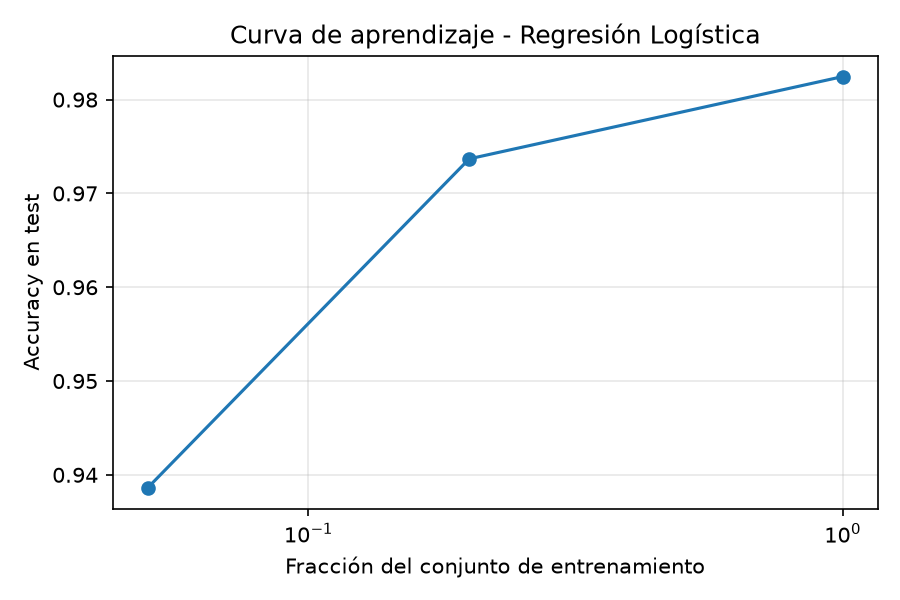

demo-B t2 probabilidades.png


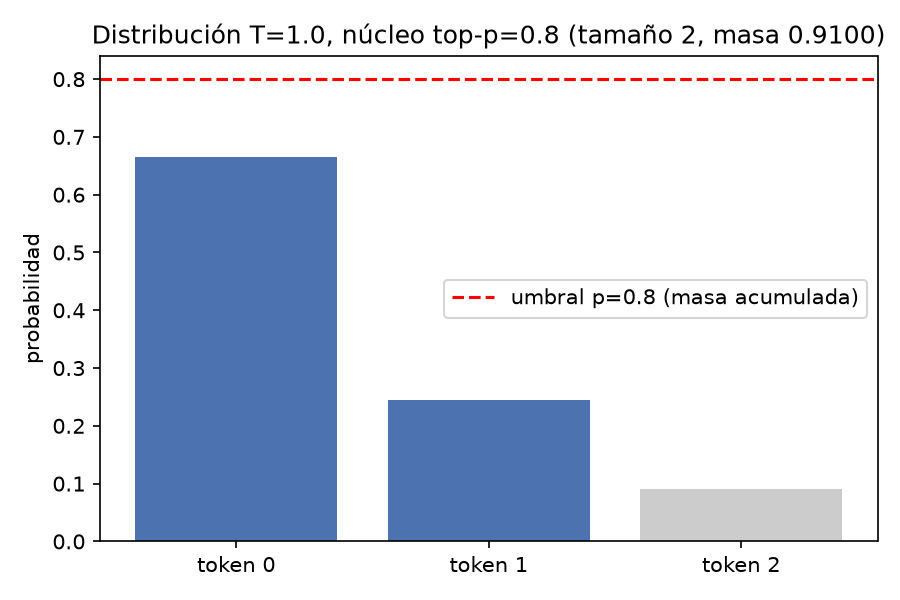

In [10]:
# Las figuras siguientes proceden de procesos científicos registrados.
for case in ['demo-A','demo-B']:
    data=load('corridas/tarea-'+case+'-completo-kit/resultados_verificados.json')
    for tid,value in data.items():
        for figure in value.get('figures',[]):
            print(case,tid,figure)
            display(Image(filename=str(artifact(value['execution_path'])/figure)))

### Tres comprobaciones peores y atribución por traza

Se seleccionan fallos del baseline y de la ablación, priorizando cifras, restricciones e integridad antes de formato. En cada uno se muestra la comprobación, el contexto que recibió el programador, lo producido y la decisión del código o del crítico. La responsabilidad se asigna a una etapa verificable; no se deduce de la fluidez de la explicación. Los JSON y scripts completos quedan en el directorio de la corrida.

**control-3-igualdad_w2 (completo).** Apunta a programador y crítico. El script afirma igualdad de candidatos en el punto indicado, pero el oracle calculado la contradice. La crítica genérica aprobó el script sin detectar esa afirmación conceptual falsa. El evaluador registró: Posición w=2.0: A=10.0; B=4.0; igualdad calculada=False; afirmación detectada=True. Diagnóstico post hoc de salida o texto del script: en coincidir en un punto (de hecho g_A(2) = g_B(2) = 10). Para acercarse a una conclusion mas gen. Se localizó la evidencia en la subtarea `t5`, con 1 llamadas al programador y 1 decisiones del crítico. Su última decisión fue `approved=True`. El notebook muestra el contexto relevante, el fragmento responsable y la decisión; la traza conserva los mensajes íntegros. Evidencia: `corridas/tarea-control-3-completo-kit/traza.jsonl`, `resultados_verificados.json` y el script en `subtareas/t5/`.

**control-3-igualdad_w_tercio (completo).** Apunta a programador y crítico. El script afirma igualdad de candidatos en el punto indicado, pero el oracle calculado la contradice. La crítica genérica aprobó el script sin detectar esa afirmación conceptual falsa. El evaluador registró: Posición w=0.3333333333333333: A=-1.6666666666666667; B=-1.0; igualdad calculada=False; afirmación detectada=True. Diagnóstico post hoc de salida o texto del script: unto y divergir en otros (de hecho g_A y g_B coinciden en w = 1 y w = 1/3). "
          "Otra comprobación sin program. Se localizó la evidencia en la subtarea `t3`, con 2 llamadas al programador y 2 decisiones del crítico. Su última decisión fue `approved=True`. El notebook muestra el contexto relevante, el fragmento responsable y la decisión; la traza conserva los mensajes íntegros. Evidencia: `corridas/tarea-control-3-completo-kit/traza.jsonl`, `resultados_verificados.json` y el script en `subtareas/t3/`.

**control-3-csv_integridad (sin_grafo).** Apunta a programador y crítico. Una fila del CSV perdió un cero válido y quedó vacía. Los resultados JSON correctos no bastan para aprobar la integridad del archivo tabular. El evaluador registró: Todos los CSV conservan tres pasos y ceros numéricos; se aceptan alias explícitos con el mismo significado.. Se localizó la evidencia en la subtarea `t2`, con 1 llamadas al programador y 1 decisiones del crítico. Su última decisión fue `approved=True`. El notebook muestra el contexto relevante, el fragmento responsable y la decisión; la traza conserva los mensajes íntegros. Evidencia: `corridas/tarea-control-3-sin_grafo-kit/traza.jsonl`, `resultados_verificados.json` y el script en `subtareas/t2/`.

In [11]:
analysis=load('evidencia/analisis_fallos_kit.json')
for item in analysis:
    events=[json.loads(line) for line in (BASE/item['trace']).read_text().splitlines()]
    programs=[e for e in events if e['event']=='llm_call' and e['agent']=='programador' and json.loads(e['input']).get('task',{}).get('id')==item['evidence_task']]
    value=load(str(Path(item['trace']).parent/'resultados_verificados.json'))[item['evidence_task']]
    source=(artifact(value['execution_path'])/'script.py').read_text()
    relevant=[line for line in source.splitlines() if any(term in line for term in ['g_A','g_B','coincid','gA','gB','igual','discrepancia','writerow','g_num','aproximacion'])]
    display(Markdown('**'+item['check']+'** · subtarea `'+item['evidence_task']+'`'))
    if programs:
        proposal=json.loads(programs[-1]['input'])
        display(Markdown('Contexto recibido (extracto):\n\n'+str(proposal.get('context',''))[:1200]))
    display(Markdown('Fragmento del script ejecutado:\n```python\n'+'\n'.join(relevant)[:1600]+'\n```'))
    display({'evaluación':item['evaluation'],'decisión_crítico':item['critic_decisions'][-1].get('decision',{}) if item['critic_decisions'] else None})
    if item['check'].endswith('csv_integridad'):
        for f in artifact(value['execution_path']).glob('*.csv'): display(pd.read_csv(f))
    print('Evidencia íntegra:',item['trace'])

**control-3-igualdad_w2** · subtarea `t5`

Contexto recibido (extracto):

[{'citation': '/Users/alech/Documents/notes/Obsidian/posgrado/master/IA GENERATIVA Y AGENTES/talleres/taller 3/solver-v2/enunciados/control-3.pdf páginas [1]', 'id': 'introduccion', 'title': 'Introducción', 'text': 'CONTROL DE LECTURA 3\nVerificación numérica de gradientes mediante diferencias finitas\nDuración: 20 minutos | Modalidad: individual | Entrega: notebook (.ipynb) o script (.py)\nObjetivo. Contrastar dos gradientes candidatos con diferencias centrales e interpretar el efecto del paso y de la\nprecisión numérica.\nContexto\nSe proporcionan una función y dos candidatos a su derivada. Determine cuál es compatible con la evidencia\nnumérica en w = 2, sin derivar a mano ni entrenar.\nf(w) =w3− 2w;g (w) = 3w2− 2;g (w) = 3w − 2\nA B\nTareas\n1 Registrar una predicción\nResponda P0 antes de ejecutar y conserve su predicción aunque después deba corregirla.\n2 Completar una función\nComplete solo la expresión pendiente de diferencia_central(f, w, h), usando el método central estudiado. No use la\nderivada analítica ni los candidatos. El resto está proporcionado.\n3 Ejecutar y observar\nEjecute estos casos con flooat de Python, sin redondear cálculos. Observe las aproximaciones, ca

Fragmento del script ejecutado:
```python
    "la aproximacion numerica de la derivada obtenida con diferencias finitas "
    "Prediccion sobre h: NO, un h menor no siempre mejora la aproximacion. Con h grande "
def g_A(w):
def g_B(w):
    dA = abs(aprox - g_A(w))
    dB = abs(aprox - g_B(w))
        "aproximacion_central": aprox,
        "candidato_A": g_A(w),
        "candidato_B": g_B(w),
        "discrepancia_A": dA,
        "discrepancia_B": dB,
        "w_mas_h_igual_w": 1.0 if w_mas == w else 0.0,
        "w_menos_h_igual_w": 1.0 if w_menos == w else 0.0,
# Evidencia de igualdad real de los puntos perturbados (coherente con t3)
assert filas[2]["w_mas_h_igual_w"] == 1.0 and filas[2]["w_menos_h_igual_w"] == 1.0
assert filas[1]["w_mas_h_igual_w"] == 0.0 and filas[1]["w_menos_h_igual_w"] == 0.0
    escritor.writerows(filas)
    "El candidato compatible con la evidencia es g_A(w) = 3w^2 - 2. Con h = 1e-5 la "
    "aproximacion central vale {a} y las discrepancias absolutas son "
    "|aprox - g_A(2)| = {dA} y |aprox - g_B(2)| = {dB}. La discrepancia con A es del orden "
    "~6, varios ordenes mayor. Con h = 1e-1 la aproximacion es {a1} (discrepancias "
    "{dA1} y {dB1}), tambien favorable a A pero con mas truncamiento. g_B queda descartado."
).format(a=r2["aproximacion_central"], dA=r2["discrepancia_A"], dB=r2["discrepancia_B"],
         a1=r1["aproximacion_central"], dA1=r1["discrepancia_A"], dB1=r1["discrepancia_B"])
    "Con h = 1e-16 la aproximacion colapsa a {a16}, mientras con h = 1e-5 vale {a5}. "
    "(igualdad real: w+h==w -> {eq1}, w-h==w -> {eq2}), porque 1e-16 esta por debajo de "
).format(a16=r3["
```

{'evaluación': 'Posición w=2.0: A=10.0; B=4.0; igualdad calculada=False; afirmación detectada=True. Diagnóstico post hoc de salida o texto del script: en coincidir en un punto (de hecho g_A(2) = g_B(2) = 10). Para acercarse a una conclusion mas gen',
 'decisión_crítico': {'approved': True,
  'correction': "La entrega cumple el enunciado: incluye nombre y función, P0 registrada antes de ejecutar y conservada, implementación de diferencia_central sin usar derivada analítica ni candidatos, los tres casos (h=1e-1, 1e-5, 1e-16) en la evidencia y en resultados_control_3.csv, y respuestas P1–P3 citando valores concretos. Los números son plausibles y consistentes: f'(2)=10, g_A(2)=10, g_B(2)=4; con h=1e-5 la discrepancia con A (~2e-10) es varios órdenes menor que con B (~6); con h=1e-16, 2.0±1e-16 == 2.0 (ULP en 2.0 es ~4.4e-16), la aproximación colapsa a 0.0 y las igualdades reales coinciden con los asserts. P2 y P3 son correctas y coherentes con P0. Declara explícitamente que no hay partes p

Evidencia íntegra: corridas/tarea-control-3-completo-kit/traza.jsonl


...

Contexto recibido (extracto):

[{'heading': 'Introducción', 'start': 0, 'end': 2042, 'text': '# Introducción\nCONTROL DE LECTURA 3\nVerificación numérica de gradientes mediante diferencias finitas\nDuración: 20 minutos | Modalidad: individual | Entrega: notebook (.ipynb) o script (.py)\nObjetivo. Contrastar dos gradientes candidatos con diferencias centrales e interpretar el efecto del paso y de la\nprecisión numérica.\nContexto\nSe proporcionan una función y dos candidatos a su derivada. Determine cuál es compatible con la evidencia\nnumérica en w = 2, sin derivar a mano ni entrenar.\nf(w) =w3− 2w;g (w) = 3w2− 2;g (w) = 3w − 2\nA B\nTareas\n1 Registrar una predicción\nResponda P0 antes de ejecutar y conserve su predicción aunque después deba corregirla.\n2 Completar una función\nComplete solo la expresión pendiente de diferencia_central(f, w, h), usando el método central estudiado. No use la\nderivada analítica ni los candidatos. El resto está proporcionado.\n3 Ejecutar y observar\nEjecute estos casos con flooat de Python, sin redondear cálculos. Observe las aproximaciones, candidatos y\ndiscrepancias absolutas, además de los puntos perturbados y su igualdad real.\nUse w = 2.0 y los pasos h = 1e-1, 1e-5 y 1e-16

Fragmento del script ejecutado:
```python
def gA(w):
def gB(w):
    dA = abs(aprox - gA(w))
    dB = abs(aprox - gB(w))
        "puntos_iguales": (w + h) == (w - h),
        "aproximacion_central": aprox,
        "gA": gA(w),
        "gB": gB(w),
        "discrepancia_gA": dA,
        "discrepancia_gB": dB,
    writer.writerows(filas)
mejor = min(filas, key=lambda r: min(r["discrepancia_gA"], r["discrepancia_gB"]))
    "aprox_h_1e-1": filas[0]["aproximacion_central"],
    "aprox_h_1e-5": filas[1]["aproximacion_central"],
    "aprox_h_1e-16": filas[2]["aproximacion_central"],
    "discrepancia_gA_h_1e-5": filas[1]["discrepancia_gA"],
    "discrepancia_gB_h_1e-5": filas[1]["discrepancia_gB"],
    "discrepancia_gA_h_1e-16": filas[2]["discrepancia_gA"],
    "discrepancia_gB_h_1e-16": filas[2]["discrepancia_gB"],
    "candidato_elegido_gA": 1.0 if mejor["discrepancia_gA"] < mejor["discrepancia_gB"] else 0.0,
```

{'evaluación': 'Todos los CSV conservan tres pasos y ceros numéricos; se aceptan alias explícitos con el mismo significado.',
 'decisión_crítico': {'approved': True, 'correction': ''}}

,student_name,h,w,w_mas_h,w_menos_h,puntos_iguales,aproximacion_central,gA,gB,discrepancia_gA,discrepancia_gB
0,Alejandro Chavez,1.000000e-01,2.0,2.10000,1.90000,False,10.01,10.0,4.0,1.000000e-02,6.01
1,Alejandro Chavez,1.000000e-05,2.0,2.00001,1.99999,False,10.00,10.0,4.0,1.987388e-10,6.00
2,Alejandro Chavez,1.000000e-16,2.0,2.00000,2.00000,True,0.00,10.0,4.0,1.000000e+01,4.00


Evidencia íntegra: corridas/tarea-control-3-sin_grafo-kit/traza.jsonl


## Parte 3. Cuatro frenos forzados

Se forzó cada freno con un cliente de guion, sin inferencia H200. Presupuesto: se verifica antes de pedir y reserva al redactor; el trabajo no realizado queda explícito en una entrega parcial. Intentos y repetición: el mismo hash rechazado no vuelve a ejecutarse, la subtarea falla al tope y sigue una independiente. Timeout: el ejecutor mata el grupo de procesos del bucle infinito. Red: una descarga crea `solicitud_red.json` ligada a hashes y queda bloqueada antes del proceso hasta aprobación humana.

La descarga bloqueada no se realizó ni se simuló una aprobación. La reanudación con un checkpointer es la opción D del taller; aquí se eligió C. La evidencia requerida del freno es bloquear antes de salir a red, y está registrada. La prueba de timeout utiliza un límite de 1,5 segundos que permite arrancar el intérprete local y registra la continuación de la tarea independiente.

| Freno       | Estado   |   Procesos | Red solicitada   | Red ejecutada   | Entrega guardada   |   Llamadas H200 |
|:------------|:---------|-----------:|:-----------------|:----------------|:-------------------|----------------:|
| presupuesto | parcial  |          0 | False            | False           | True               |               0 |
| repeticion  | parcial  |          2 | False            | False           | True               |               0 |
| timeout     | parcial  |          2 | False            | False           | True               |               0 |
| red         | parcial  |          1 | True             | False           | True               |               0 |

In [12]:
brakes=load('solver-v2/frenos/resumen.json')
display(pd.DataFrame([{k:b[k] for k in ['freno','status','ejecuciones','red_solicitada','red_ejecutada','entrega_existente','llamadas_remotas']} for b in brakes]))
assert all(b['entrega_existente'] and b['llamadas_remotas']==0 for b in brakes)
assert not any(b['red_ejecutada'] for b in brakes)
assert brakes[0]['guard_prellamada']['blocked_before_request']
assert brakes[0]['guard_prellamada']['requests_before_writer']==0
for mode in ['repeticion','timeout','red']:
    row=next(b for b in brakes if b['freno']==mode)
    assert any(t['id']=='t2' and t['status']=='aprobado' for t in row['subtareas'])

,freno,status,ejecuciones,red_solicitada,red_ejecutada,entrega_existente,llamadas_remotas
0,presupuesto,parcial,0,False,False,True,0
1,repeticion,parcial,2,False,False,True,0
2,timeout,parcial,2,False,False,True,0
3,red,parcial,1,True,False,True,0


## Parte 4. Una extensión medida: memoria de scripts aprobados

Se eligió la opción C después de medir el baseline. Los scripts aprobados se guardan como nodos con hash, tarea, resultados, dataset fuente y cita de traza. Se enlazan con métodos y datasets; las tareas siguientes recuperan ejemplos por similitud de descripción. La memoria no concede aprobación: cada script propuesto atraviesa otra vez la guarda, ejecución y crítica.

Las cinco tareas se ejecutaron también con memoria y con el mismo golden. Se distingue coste de preparar la teoría, consumo por corrida e intentos de código. La memoria se sembró con scripts del baseline: mide reutilización de ejemplos de estos casos, no generalización a casos desconocidos. Solo se guardan scripts que llegaron a aprobación del crítico; esa aprobación puede ser errónea, como muestran los fallos. La comparación agregada y por tarea está en las tablas anteriores. Algunas salidas y textos de scripts aprobados contienen afirmaciones falsas de igualdad entre candidatos. Se conservan como evidencia y se señalan con checks semánticos; el informe final no las adopta como explicación correcta.

In [13]:
display(s[s.variante.isin(['completo','memoria'])])
display(r.groupby('variante')[['tokens_entrada','tokens_salida','intentos_codigo','pared_s']].sum())
files=list((BASE/'solver-v2/memoria').glob('*.json'))
print('Scripts aprobados guardados:',len(files))
assert files
item=json.loads(files[0].read_text());display({k:v for k,v in item.items() if k in ['node_type','task','pdf_sha256']})

,variante,tarea,aprobados,total_checks,centrales_aprobados,centrales_total,procedencia
0,completo,control-1,8,8,8,8,1.0
1,completo,control-3,11,13,11,11,1.0
2,completo,demo-A,13,13,8,8,1.0
3,completo,demo-B,12,12,9,9,1.0
4,completo,demo-C,9,9,8,8,1.0
5,memoria,control-1,8,8,8,8,1.0
6,memoria,control-3,10,13,10,11,1.0
7,memoria,demo-A,12,13,7,8,1.0
8,memoria,demo-B,12,12,9,9,1.0
9,memoria,demo-C,9,9,8,8,1.0


,tokens_entrada,tokens_salida,intentos_codigo,pared_s
variante,,,,
completo,259066,63773,13,612.729827
memoria,291830,60768,11,630.500265
sin_grafo,206743,67221,14,506.418510


Scripts aprobados guardados: 21


{'node_type': 'approved_script',
 'task': 'Escribir script/notebook que: (1) cree para cada n en [10000, 50000, 100000] una list con ids 0..n-1 y un dict con esas claves; (2) genere 200 valores inexistentes (>= n); (3) mida con time.perf_counter() el tiempo total de 200 búsquedas en list y en dict, excluyendo la construcción; (4) muestre tabla con n, list_ms, dict_ms en milisegundos.',
 'pdf_sha256': '1c34038cd7415ce884bb305205fc12f63c5d90171838da3045c554921b6a51a6'}

## Parte 5. Reflexión basada en las mediciones

Las respuestas se redactaron mediante H200 a partir de los CSV finales. Se declara la asistencia y se comprueba que cada respuesta tenga entre 100 y 150 palabras.

### Dónde vive el objetivo

El objetivo vive en el pipeline de resolución: Solver.solve orquesta el flujo, validate_plan verifica que el plan cumpla condiciones antes de ejecutar, y render_provenance produce la evidencia trazable del resultado. El estado completado no es decorativo: exige writer_valid (el escrito pasó sus validaciones), format_valid (el formato es correcto) y que todas las subtareas estén aprobadas; si falta cualquiera, el estado no puede ser completado. Conviene distinguir dos niveles de aprobación: la golden externa, independiente, que decide los requisitos medidos como checks y accuracy, y la aprobación académica del profesor o persona evaluadora, que es un juicio distinto. Un error común es confundir aprobación genérica con verdad científica: aprobar checks demuestra cumplimiento de criterios definidos, no validez universal de las conclusiones.

### Qué compró el grafo y quién gastó más

Excluyendo la preparación común, el rol de mayor consumo es el indexador: 142447 tokens en la variante completo, 123574 en sin_grafo y 113842 en memoria. Este alcance corresponde a la fase de indexación de documentos, no a la escritura ni a la crítica. Al comparar completo contra sin_grafo, las cinco tareas completas gastaron 259066 tokens de entrada y 63773 de salida, con 13 intentos de código; sin_grafo gastó 206743 de entrada y 67221 de salida, con 14 intentos. En checks, completo aprobó 53 de 55 (44 de 44 centrales) y sin_grafo 47 de 55 (37 de 44 centrales). La preparación común (280902 tokens de entrada, 82177 de salida, 130 llamadas LLM) se amortiza aparte y no debe sumarse al consumo por rol. Como hubo una sola corrida por tarea y los planes varían entre corridas, estos números describen lo observado: no permiten afirmar causalidad ni ahorro de velocidad entre variantes.

### Uso honesto y daño

Para un uso honesto hay que declarar que el kit fue reconstruido por solicitud, que la asistencia vino de H200 y Codex (distintas del trabajo del estudiante), y adjuntar scripts, PDF, CSV y trazas como evidencia. El caso de falla con exit0 y accuracy1 en presencia de una fuga demuestra que la ejecución exitosa por sí sola no basta: el código puede terminar bien y aun así hacer daño. Los cuatro frenos son: presupuesto con reserva, control de intentos y repetición, timeout con killpg para matar el grupo de procesos, y revisión humana antes de cualquier acceso a red. Los daños posibles si el sandbox falla incluyen leer archivos, exfiltrar datos, borrar contenido o agotar recursos. Conviene no sobreactuar: el análisis AST no prueba seguridad, y la reanudación con red no fue probada; ambas limitaciones deben declararse como incertidumbre, no como garantías.

In [14]:
reflection=load('evidencia/reflexion_kit_h200.json');lengths=[len(t.split()) for t in reflection['respuestas']]
print('Palabras por respuesta:',lengths)
assert len(lengths)==3 and all(100<=n<=150 for n in lengths)

Palabras por respuesta: [120, 150, 142]


## Ilustraciones y declaración de asistencia

Se generaron exactamente dos ilustraciones mediante Codex. No se atribuyen imágenes a Nano Banana: no se obtuvo un PNG verificable de ese servicio. Los prompts están en `evidencia/prompts_imagenes_codex.json`. Los diagramas y gráficas científicas son figuras hechas por código y se cuentan aparte.

El estudiante debe comprender y asumir el contenido: los roles H200 propusieron planes, código y redacción; Codex implementó el orquestador, organizó archivos y comprobó la entrega. Los controles PDF fueron aportados por el usuario; no se inventa una autorización docente adicional. El material y las trazas se entregan para evaluar lo que realmente ocurrió.

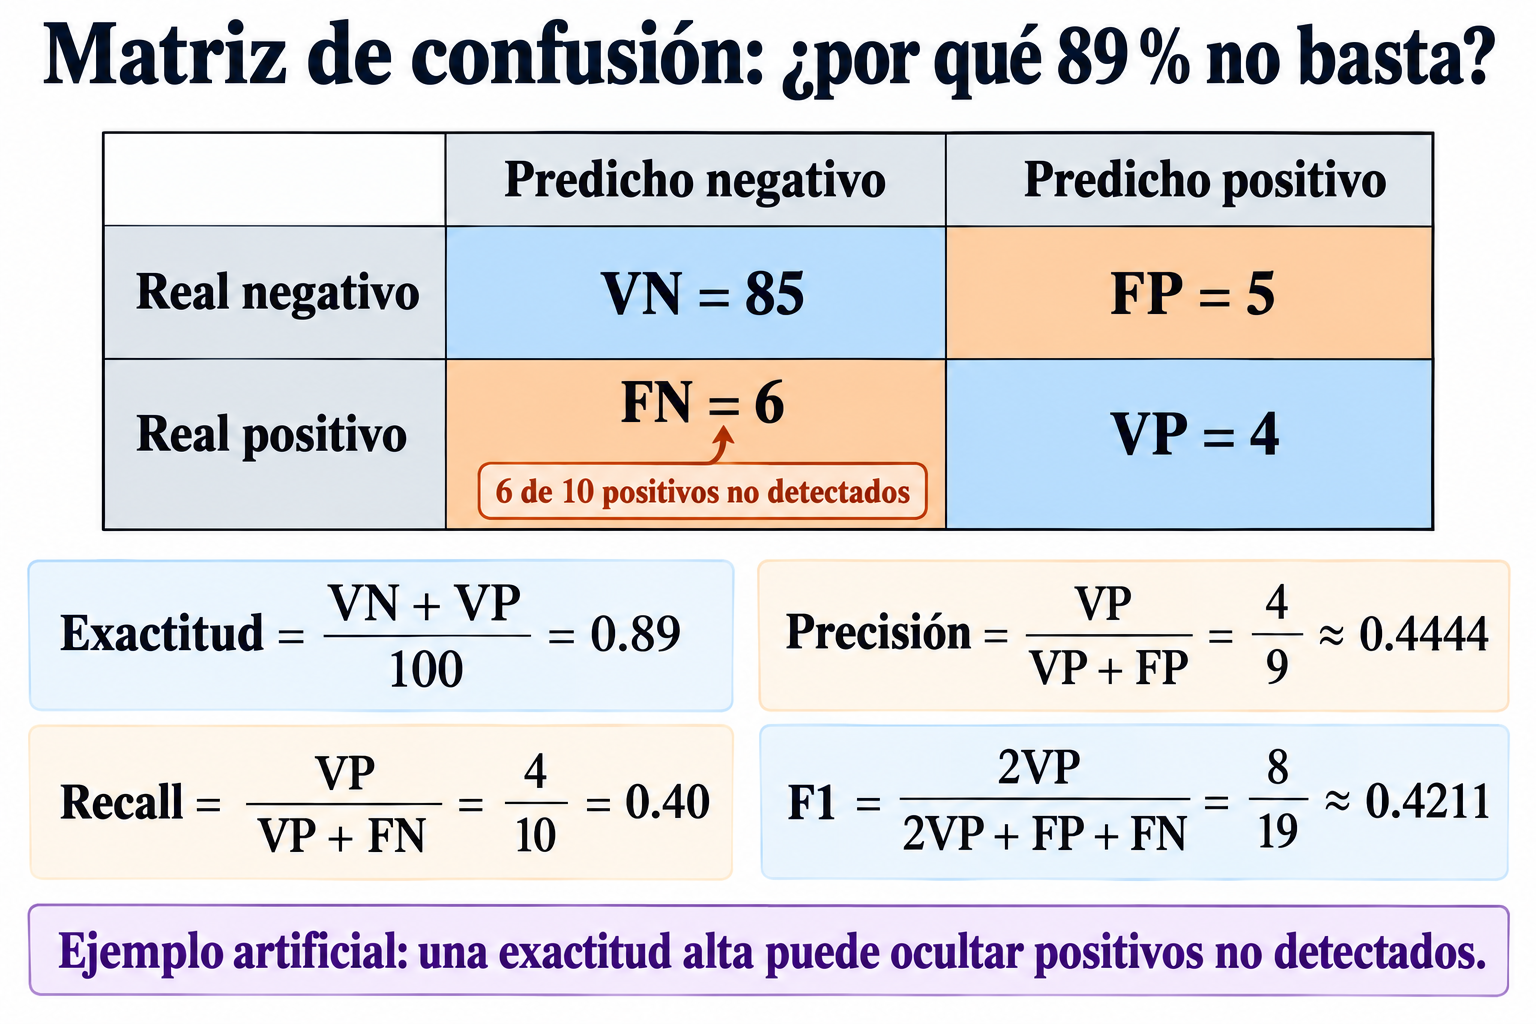

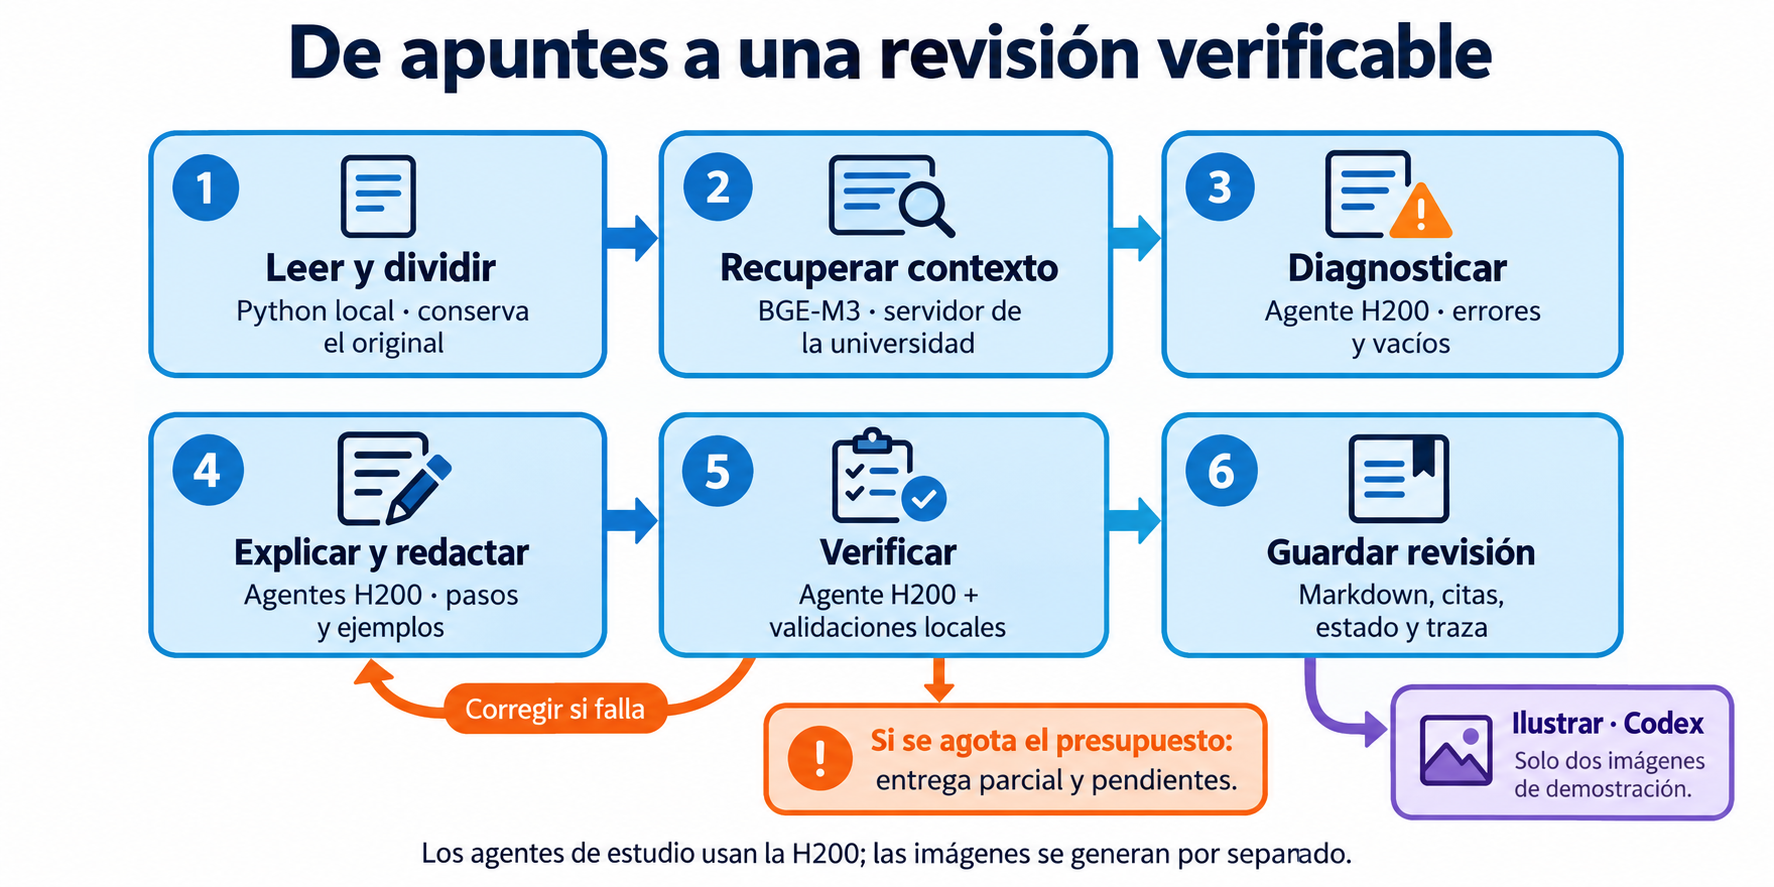

In [15]:
for name in ['codex_metricas.png','codex_agentes.png']:
    display(Image(filename=str(BASE/'imagenes'/name)))

## Reproducibilidad y archivos de entrega

El notebook permite estudiar y recalcular referencias sin VPN. Se entrega ejecutado, con salidas y figuras. Nuevas inferencias necesitan acceso a la red universitaria. El sandbox de esta implementación necesita macOS y `sandbox-exec`; si no está disponible, el ejecutor bloquea scripts en vez de ejecutarlos sin aislamiento.

Instala Python 3.12 y `requirements.txt`, registra un kernel `taller3-h200` y abre este notebook desde la carpeta extraída. `Solver().solve(pdf, salida)` expone el contrato del taller; `.run(pdf)` añade `answer` para el envoltorio siguiente. El kit incluye `evaluar_solver.py`, golden comentado, scripts de Parte 0, corpus, caché común, enunciados y manifiesto. La evaluación offline lee resultados; `--ejecutar` permite generar corridas faltantes mediante H200. Para repetir desde cero utiliza una salida nueva y no sobrescribas el historial medido.

`corridas/tarea-*-kit/` contiene directorios reales con plan, traza, código, resultados y entregables. El ZIP reúne notebook, informe PDF y fuente, código, entorno, golden, CSV, teoría, corridas y evidencia auxiliar. No incluye el entorno virtual ni claves. Las rutas históricas permanecen en trazas; el lector de artefactos del notebook resuelve las copias de la entrega al cambiar de carpeta.

In [16]:
RUN_LIVE=False
if RUN_LIVE:
    docs=load('solver-v2/material_curso.json')
    for doc in docs: doc['path']=str(BASE/'solver-v2/notas-teoricas'/doc['id'])
    result=Solver(course_documents=docs,course_index_dir=BASE/'solver-v2/indice_curso',token_budget=450000,timeout=45).solve(BASE/'solver-v2/enunciados/demo-A.pdf',BASE/'corridas/nueva-demo-A')
    display(result)
else:
    print('Sin llamadas nuevas. Para evaluar: python solver-v2/evaluar_solver.py --ruta .')

Sin llamadas nuevas. Para evaluar: python solver-v2/evaluar_solver.py --ruta .


Esta entrega desarrolla las Partes 0–5 del Taller 03 v2 con el kit reconstruido, evaluación independiente y resultados verificables, incluidos los fallos que se analizan. El conjunto experimental consta exclusivamente de las 15 corridas finales de cinco tareas y tres variantes.

Fuentes principales: `taller-03-v2-solver-multiagente.pdf`, los cinco enunciados, notas del curso con hashes, CSV crudos, trazas y `evidencia/analisis_fallos_kit.json`. Fundamentos técnicos documentados en las notas: prevención de fuga, softmax y top-p, recuperación léxica/LSA y validación de agentes. Ninguna cifra de evaluación procede de una estimación del redactor.